In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/raw_news_2025.csv.xz')

In [6]:
df['CaptureTime'] = pd.to_datetime(df['CaptureTime'])

In [7]:
df.head(5).T

,0,1,2,3,4
LanguageString,ENGLISH,ENGLISH,ENGLISH,ENGLISH,ENGLISH
DerivedTickersId,CBA@AU,KXIN;ABTS;BAOS;ONEG;ITP;PHH;MGIH;WIMI;BDMD;BAB...,KXIN;ABTS;BAOS;ONEG;ITP;386@HK;PHH;MGIH;WIMI;B...,JBERGER@NL,299795Z
AssignedTickersId,NaN,KXIN;ABTS;BAOS;ONEG;ITP;PHH;MGIH;WIMI;BDMD;BAB...,KXIN;ABTS;BAOS;ONEG;ITP;PHH;MGIH;WIMI;BDMD;BAB...,NaN,NaN
CaptureTime,2025-01-01 00:00:03.595000+00:00,2025-01-01 00:00:07.859000+00:00,2025-01-01 00:00:07.983000+00:00,2025-01-01 00:00:08.563000+00:00,2025-01-01 00:00:10.479000+00:00
Headline,OilPrice.com: Trump Could Cut China’s Supply O...,Baird Medical Investment Rises 624%: Chinese U...,Baird Medical Investment Rises 624%: Chinese U...,This Day Nigeria: We Have Shared Commitment to...,"This Day Nigeria: Jimmy Carter, Habitat for Hu..."
AssignedTopicsId,NaN,BIZNEWS;CHINAADRBA;MSCIWORLD;STKMOV;ASIAX;BUSI...,BIZNEWS;CHINAADRBA;MSCIWORLD;STKMOV;ASIAX;BUSI...,NaN,NaN
DerivedTopicsId,REPPARTY;BIZNEWS;MSCIWORLD;NORTHAM;USGOV;CPNYC...,BIZNEWS;CHINAADRBA;MSCIWORLD;STKMOV;ASIAX;BUSI...,BIZNEWS;CHINAADRBA;MSCIWORLD;STKMOV;ASIAX;BUSI...,BIZNEWS;CST;CPNYCNT1;BUSINESS;MISC;BASIC;SRCRA...,MSCIWORLD;NORTHAM;CPNYCNT1;G7MEMB;MISC;PADD3;U...
Event,ADD_STORY,ADD_1STPASS,ADD_STORY,UPDATE_ATTRIBUTE,UPDATE_ATTRIBUTE
Version,ORIGINAL,ORIGINAL,ORIGINAL,ORIGINAL,ORIGINAL
WireName,NS3,BN,BN,NS8,NS8


In [8]:
df.dtypes

LanguageString                       str
DerivedTickersId                     str
AssignedTickersId                    str
CaptureTime          datetime64[us, UTC]
Headline                             str
AssignedTopicsId                     str
DerivedTopicsId                      str
Event                                str
Version                              str
WireName                             str
dtype: object

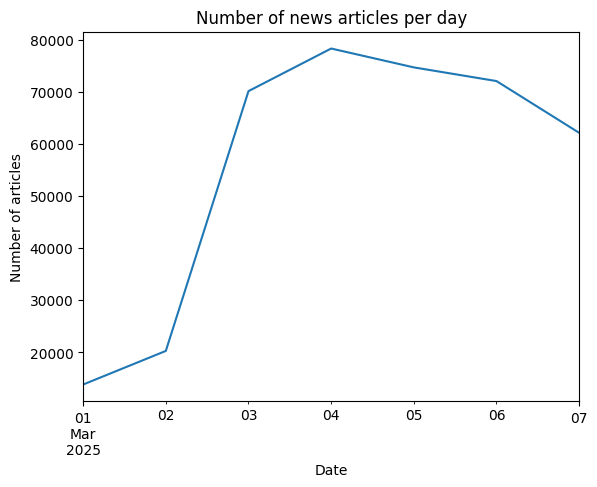

In [18]:
# select only first week of march 2025
df_march_2025 = df[(df['CaptureTime'].dt.month == 3) & (df['CaptureTime'].dt.day <= 7)]
# use pd.Grouper to group by day
df_march_2025.groupby(pd.Grouper(key='CaptureTime', freq='D')).size().plot()
plt.title('Number of news articles per day')
plt.xlabel('Date')
plt.ylabel('Number of articles')
plt.show()

In [19]:
from sklearn.feature_extraction.text import CountVectorizer

token_pattern = r"(?u)\b[^\W\d_]{3,}\b"
vectorizer = CountVectorizer(stop_words='english', min_df=10, token_pattern=token_pattern, ngram_range=(1, 2))
X = vectorizer.fit_transform(df_march_2025['Headline'])
print(X.shape)

(391523, 56426)


In [20]:
from sklearn.decomposition import NMF
nmf = NMF(n_components=50, random_state=42)
W = nmf.fit_transform(X)
H = nmf.components_
print(W.shape, H.shape)

(391523, 50) (50, 56426)


In [21]:
for k in range(50):
    top_words = [vectorizer.get_feature_names_out()[i] for i in H[k].argsort()[-10:][::-1]]
    print(f'Topic {k}: {" ".join(top_words)}')
    # print the top 5 headlines for this topic
    top_headlines = df_march_2025['Headline'].iloc[W[:, k].argsort()[-5:][::-1]]
    for headline in top_headlines:
        print(f'  - {headline}')


Topic 0: trump tariff congress trump tariffs trump tariff ukraine donald donald trump administration trump administration
  - Palm Beach Post: How tall is Barron Trump? He towers over President Donald Trump and First Lady Melania Trump
  - Naples Daily Nws: Trump Tuesday primetime address to Congress: Did Melania, Ivanka or Barron Trump attend? Trump primetime
  - India Today: Donald Trump speech live updates: Trump to address joint session of Congress amid trade war and Ukraine tensions 
  - Daily Leader: Trump speech live updates: Latest on president's address tonight; where to watch President Trump to address joint
  - Chicago NBC: Trump speech to congress: What time is President Trump's address Tuesday? How to watch
Topic 1: results quarter fourth fourth quarter reports quarter year reports fourth financial results year financial year results
  - Atea Pharmaceuti: Fourth Quarter 2024 Financial Results Conference Call Fourth Quarter 2024 Financial Results Conference Call
  - NewLake